# Imports

In [19]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# display settings
pd.set_option('display.max_columns', None)
sns.set_style("whitegrid")

# Load Data

In [20]:
import pandas as pd 

df = pd.read_csv("../data/online_shoppers_intention.csv")
df.head()



,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,Month,OperatingSystems,Browser,Region,TrafficType,VisitorType,Weekend,Revenue
0,0,0.0,0,0.0,1,0.000000,0.20,0.20,0.0,0.0,Feb,1,1,1,1,Returning_Visitor,False,False
1,0,0.0,0,0.0,2,64.000000,0.00,0.10,0.0,0.0,Feb,2,2,1,2,Returning_Visitor,False,False
2,0,0.0,0,0.0,1,0.000000,0.20,0.20,0.0,0.0,Feb,4,1,9,3,Returning_Visitor,False,False
3,0,0.0,0,0.0,2,2.666667,0.05,0.14,0.0,0.0,Feb,3,2,2,4,Returning_Visitor,False,False
4,0,0.0,0,0.0,10,627.500000,0.02,0.05,0.0,0.0,Feb,3,3,1,4,Returning_Visitor,True,False


# Dataset Overview

In [21]:
# Shape of dataset
print("Shape:", df.shape)

#column names
print("\nColumns:", df.columns.tolist())

#data types
print("\nData Types:\n", df.dtypes)

Shape: (12330, 18)

Columns: ['Administrative', 'Administrative_Duration', 'Informational', 'Informational_Duration', 'ProductRelated', 'ProductRelated_Duration', 'BounceRates', 'ExitRates', 'PageValues', 'SpecialDay', 'Month', 'OperatingSystems', 'Browser', 'Region', 'TrafficType', 'VisitorType', 'Weekend', 'Revenue']

Data Types:
 Administrative               int64
Administrative_Duration    float64
Informational                int64
Informational_Duration     float64
ProductRelated               int64
ProductRelated_Duration    float64
BounceRates                float64
ExitRates                  float64
PageValues                 float64
SpecialDay                 float64
Month                       object
OperatingSystems             int64
Browser                      int64
Region                       int64
TrafficType                  int64
VisitorType                 object
Weekend                       bool
Revenue                       bool
dtype: object


# Missing Values

In [22]:
missing = df.isnull().sum()
missing_percent = (missing / len(df)) * 100

pd.DataFrame({
    "Missing Count": missing,
    "Missing %": missing_percent
})

,Missing Count,Missing %
Administrative,0,0.0
Administrative_Duration,0,0.0
Informational,0,0.0
Informational_Duration,0,0.0
ProductRelated,0,0.0
ProductRelated_Duration,0,0.0
BounceRates,0,0.0
ExitRates,0,0.0
PageValues,0,0.0
SpecialDay,0,0.0


# Target Variable Analysis

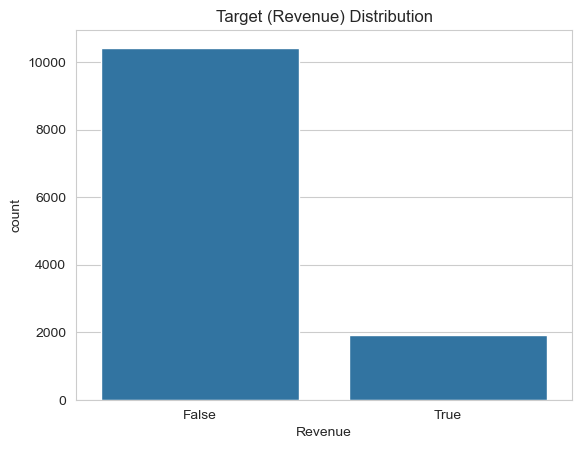

Overall Purchase Rate: 0.15474452554744525


In [23]:
df["Revenue"].value_counts()
df["Revenue"].value_counts(normalize=True)

sns.countplot(x="Revenue", data=df)
plt.title("Target (Revenue) Distribution")
plt.show()

purchase_rate = df["Revenue"].mean()
print("Overall Purchase Rate:", purchase_rate)

# Numerical Features Analysis

Administrative skewness: 1.96
Administrative_Duration skewness: 5.62
Informational skewness: 4.04
Informational_Duration skewness: 7.58
ProductRelated skewness: 4.34
ProductRelated_Duration skewness: 7.26
BounceRates skewness: 2.95
ExitRates skewness: 2.15
PageValues skewness: 6.38
SpecialDay skewness: 3.30
OperatingSystems skewness: 2.07
Browser skewness: 3.24
Region skewness: 0.98
TrafficType skewness: 1.96


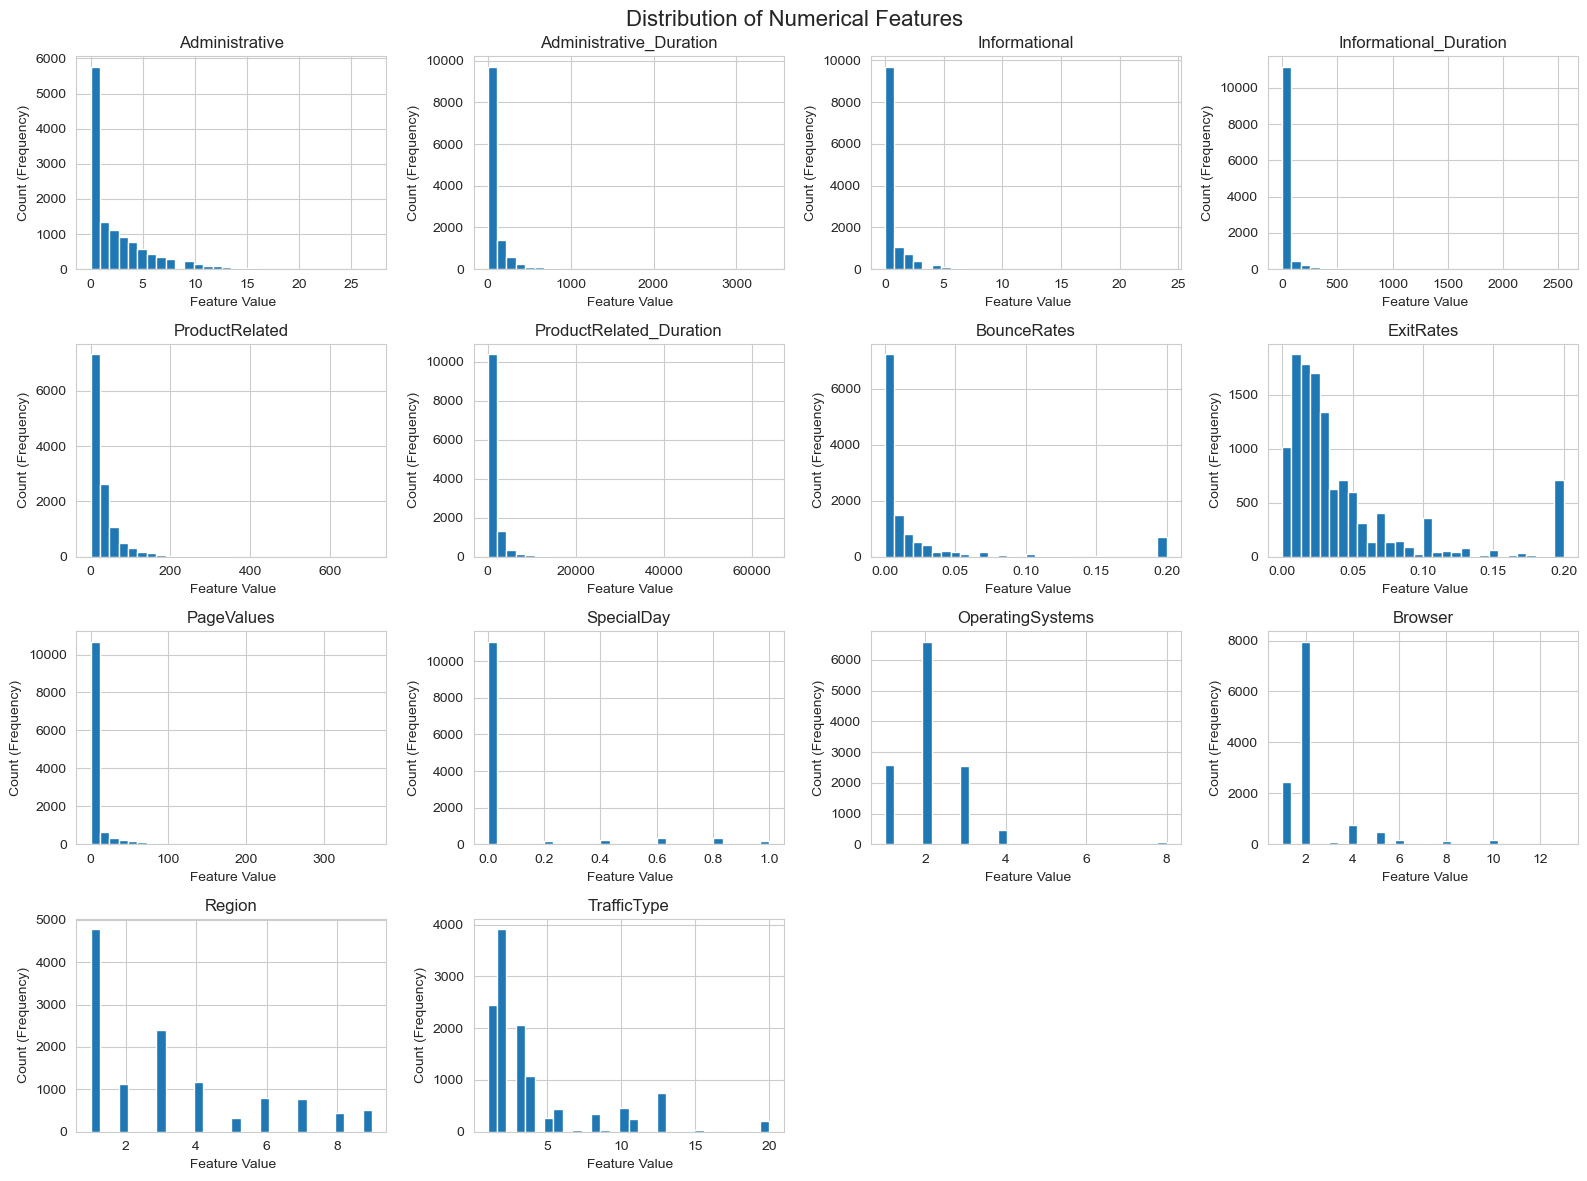

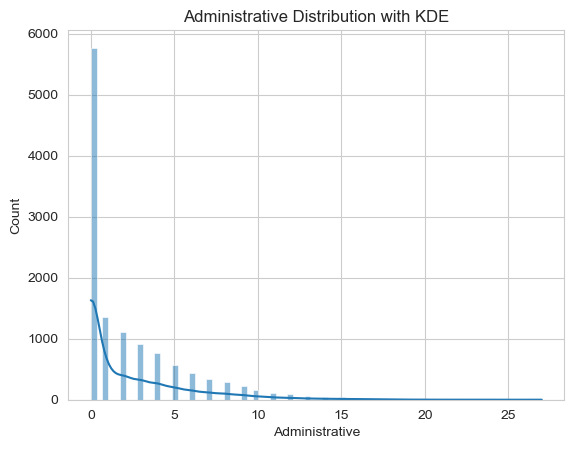

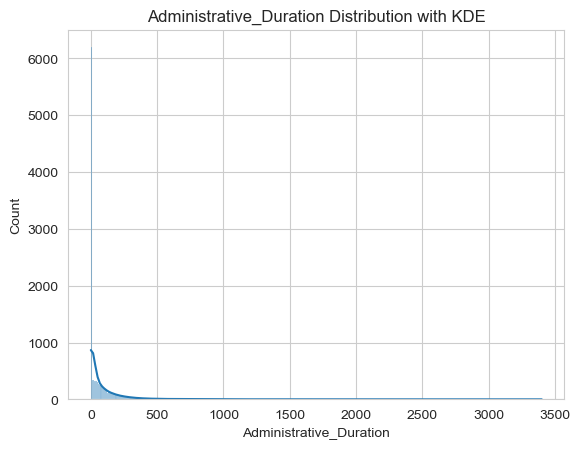

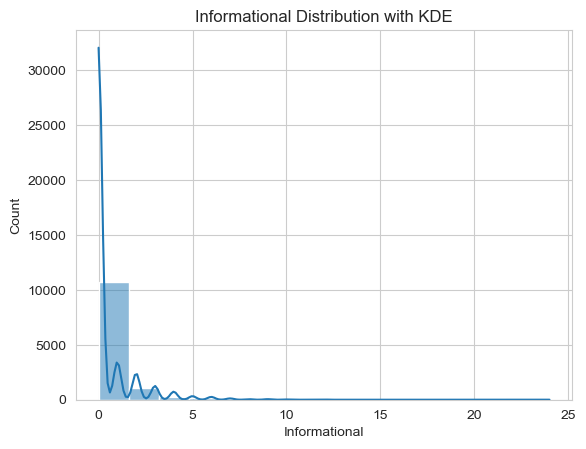

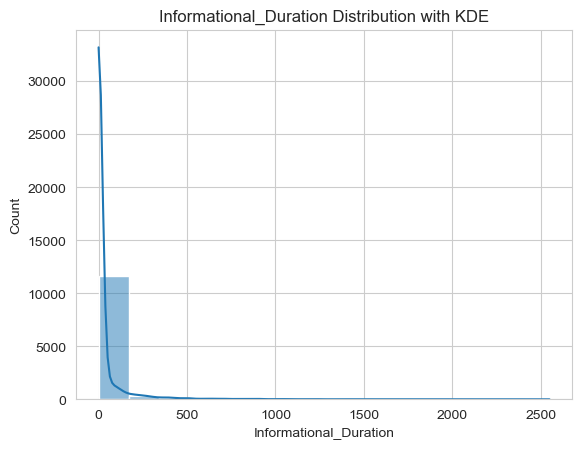

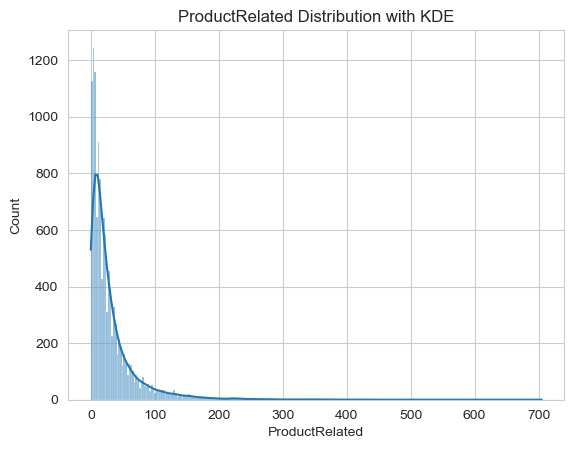

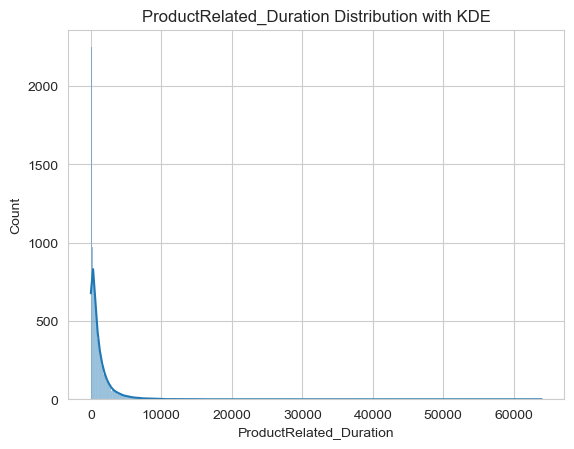

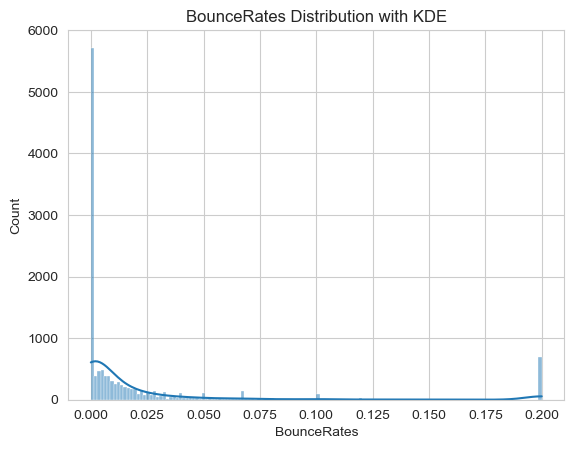

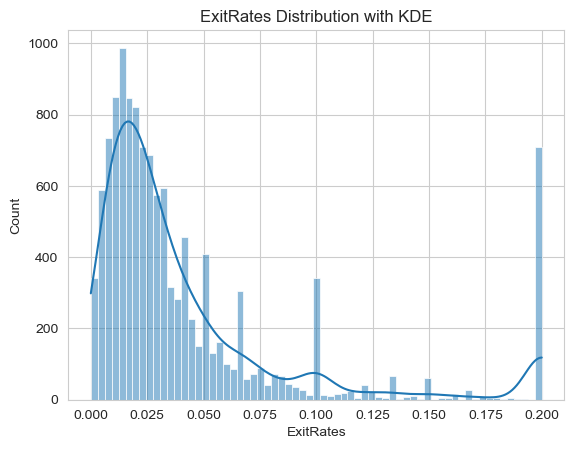

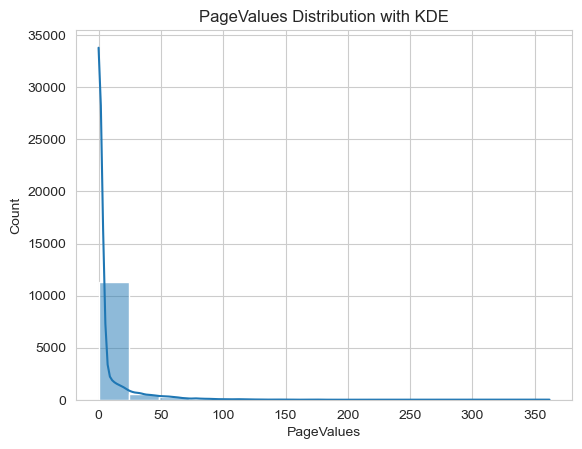

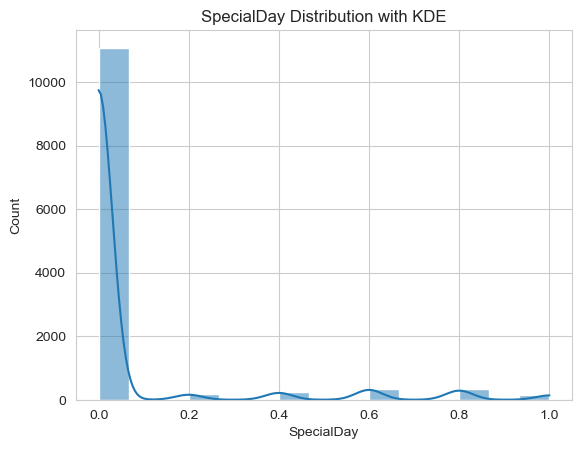

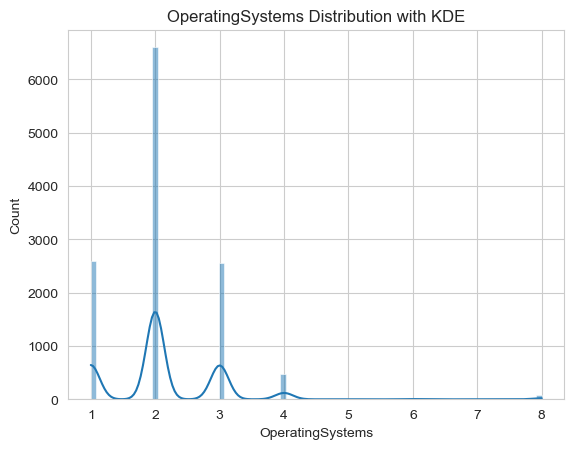

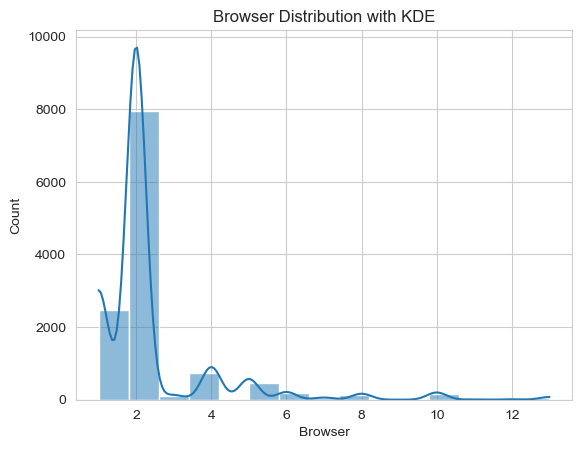

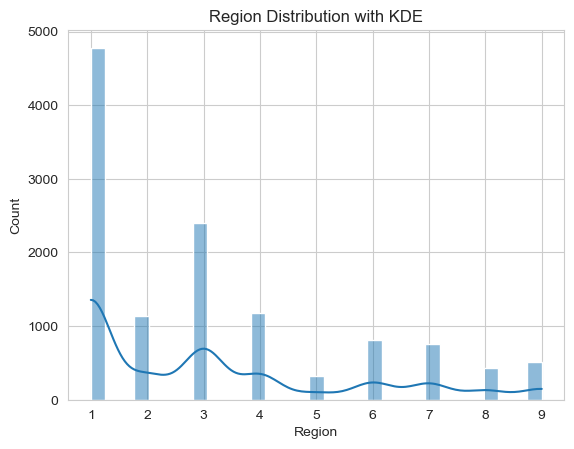

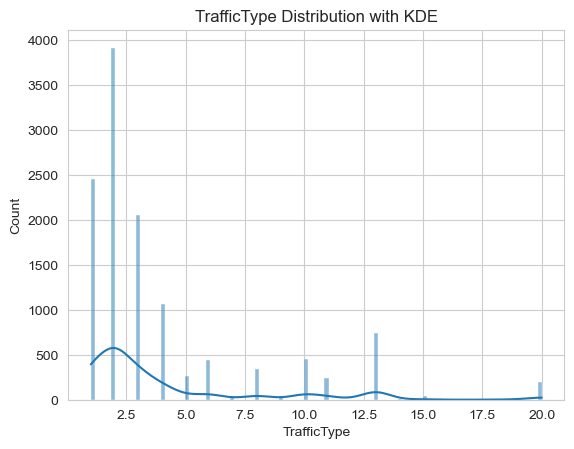

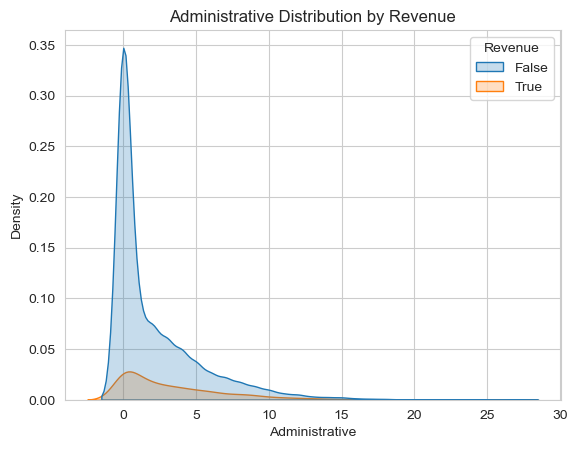

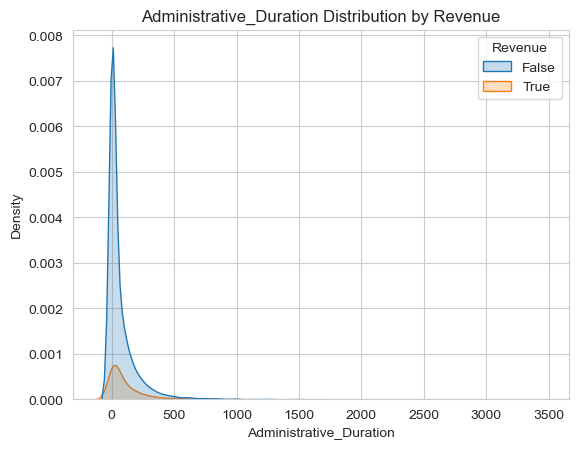

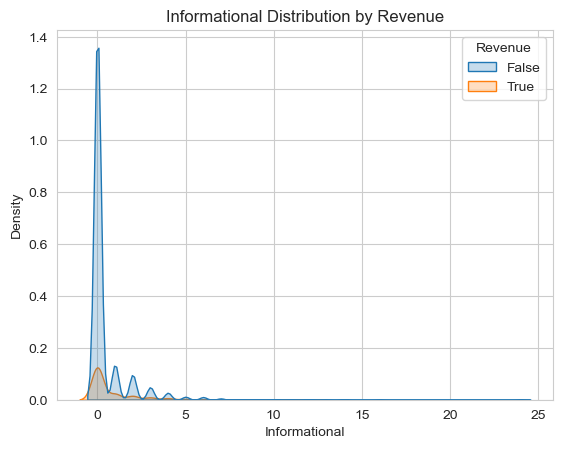

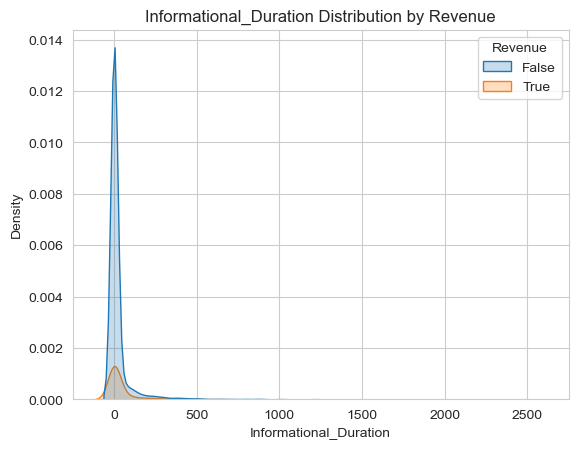

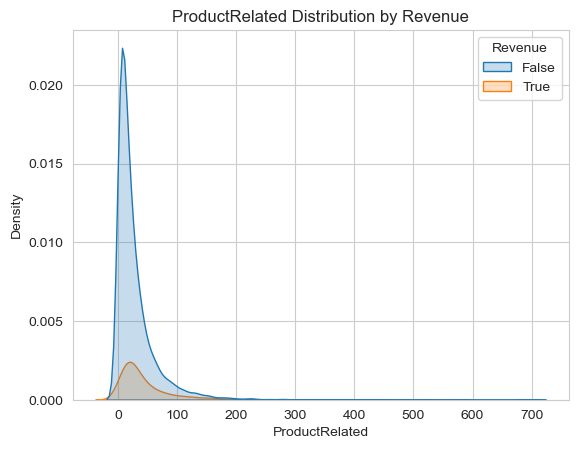

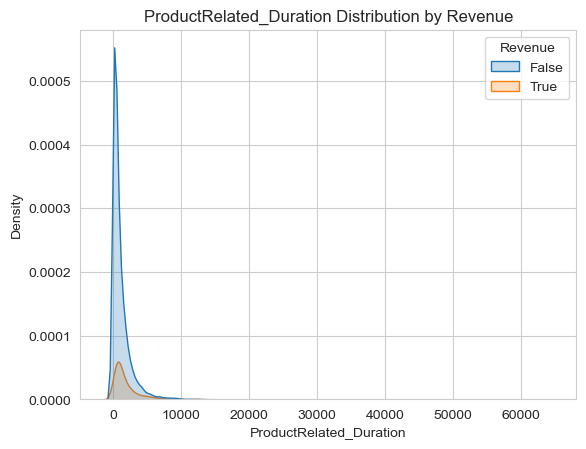

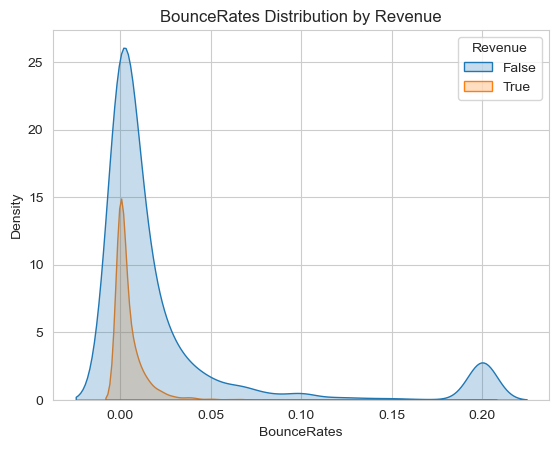

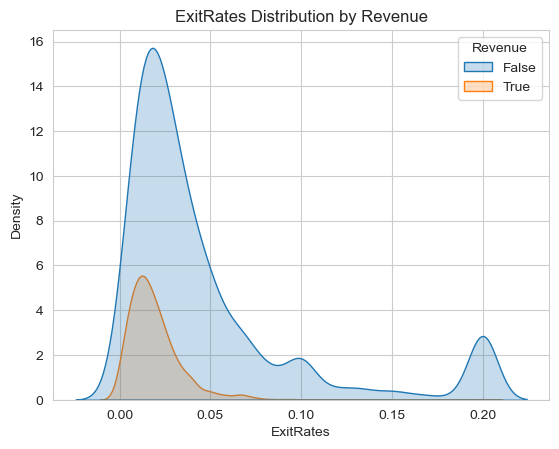

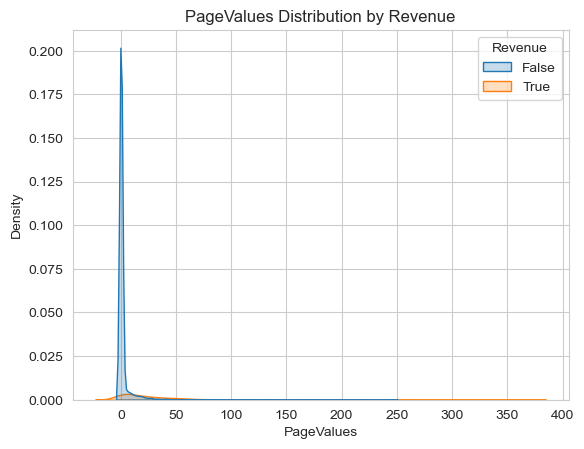

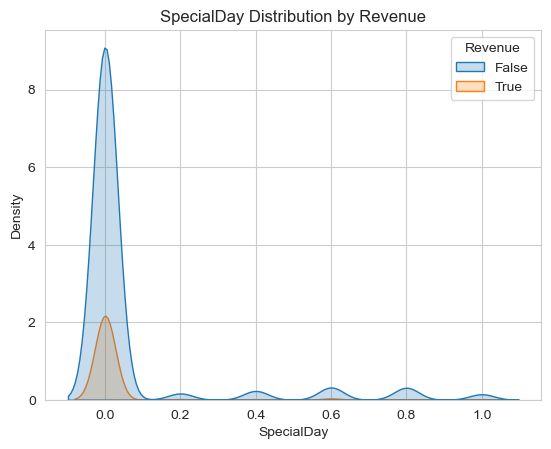

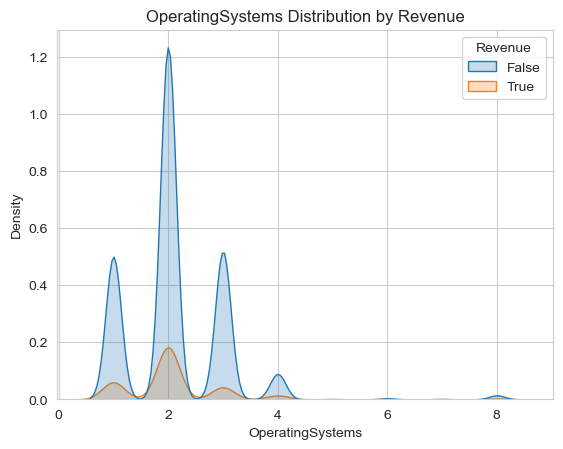

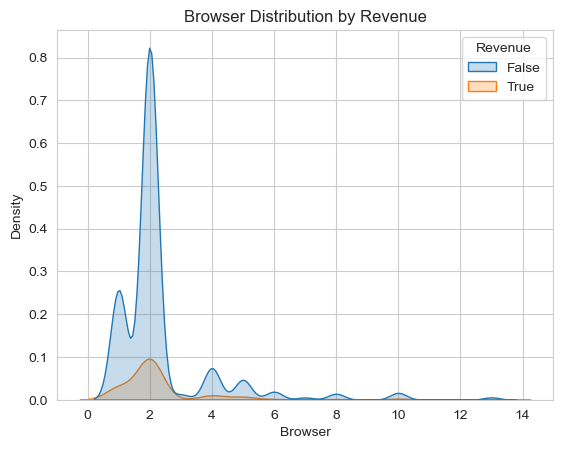

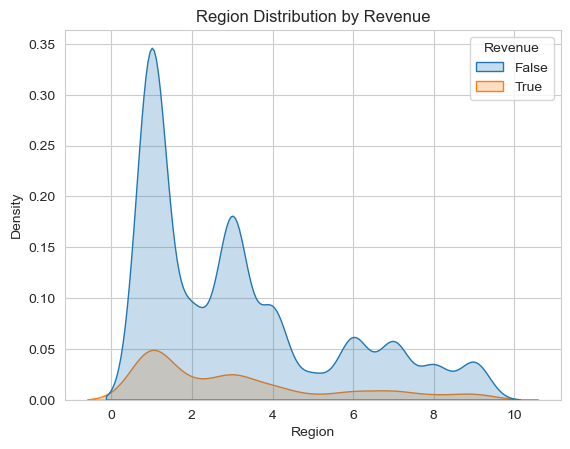

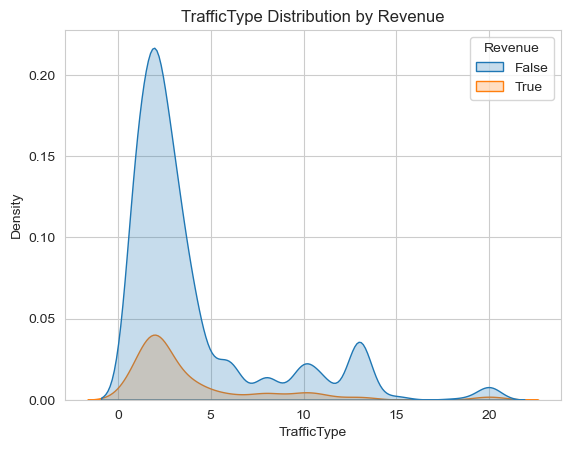

In [24]:
# Identify numerical columns
num_cols = df.select_dtypes(include=["int64", "float64"]).columns

# Summary statistics for numerical features
df[num_cols].describe().T

# Distribution + Skewness
for col in num_cols:
    print(f"{col} skewness: {df[col].skew():.2f}")
    
axes = df[num_cols].hist(figsize=(16,12), bins=30)

for ax in axes.flatten():
    ax.set_xlabel(" Feature Value")
    ax.set_ylabel("Count (Frequency)")

plt.suptitle("Distribution of Numerical Features", fontsize=16)

plt.tight_layout()
plt.show()

# Added KDE curves to visualize distribution shape
for col in num_cols:
    sns.histplot(df[col], kde=True)
    plt.title(f"{col} Distribution with KDE")
    plt.show()
    
# Compared buyers vs non-buyers
for col in num_cols:
    sns.kdeplot(data=df, x=col, hue='Revenue', fill=True)
    plt.title(f"{col} Distribution by Revenue")
    plt.show()



# Outliers

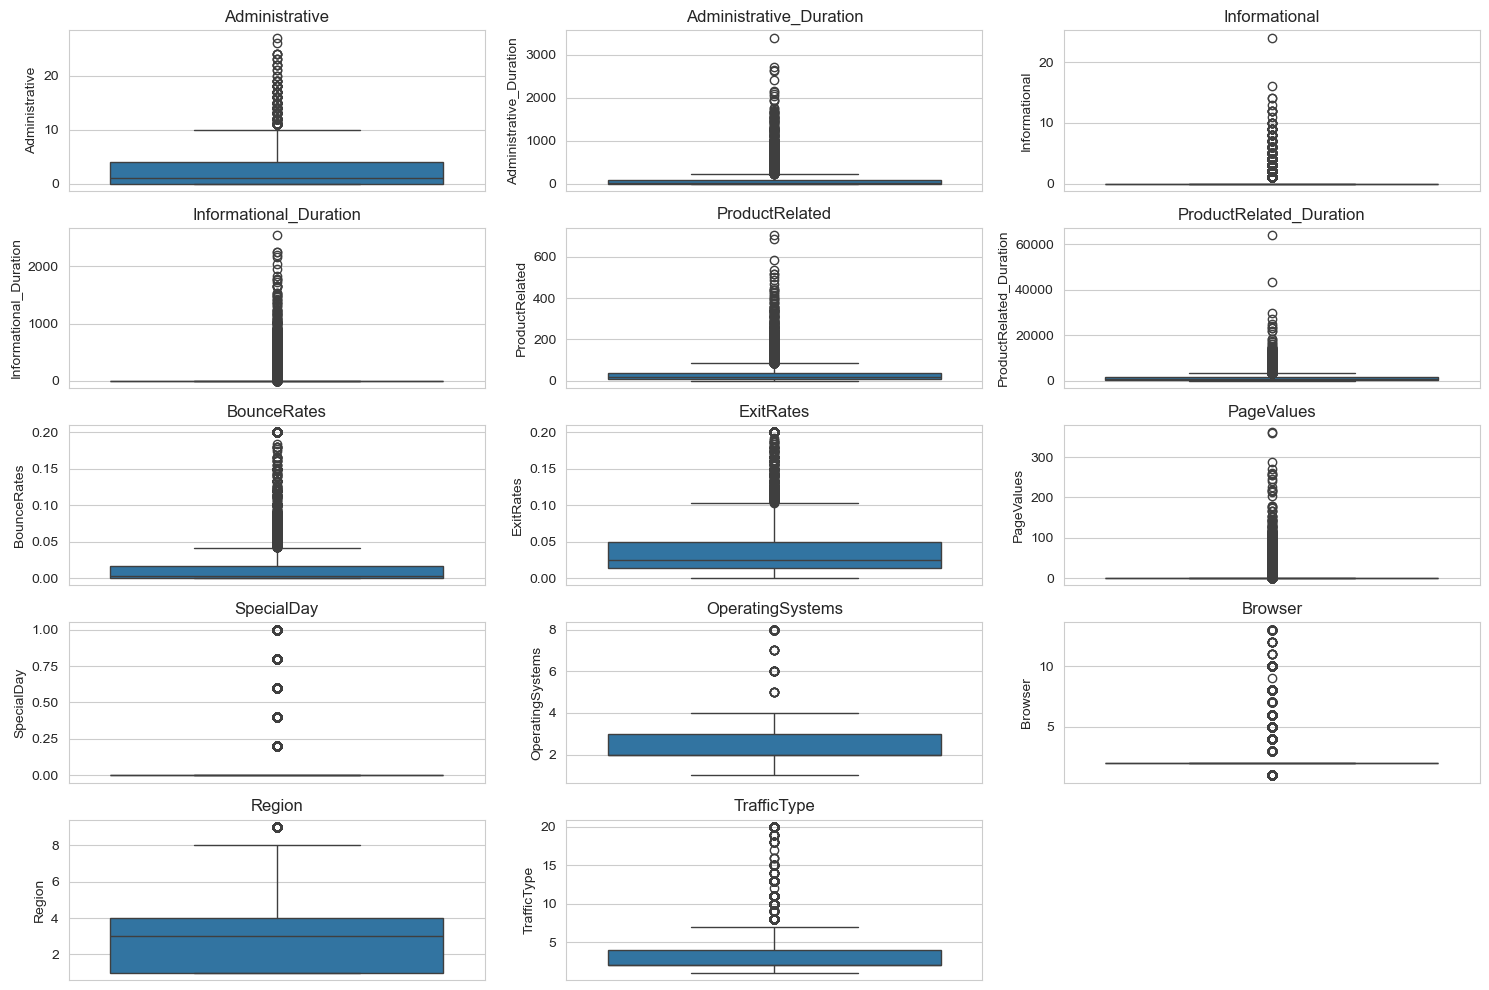

In [25]:
plt.figure(figsize=(15,10))
for i, col in enumerate(num_cols):
    plt.subplot(5, 3, i+1)
    sns.boxplot(y=df[col])
    plt.title(col)

plt.tight_layout()
plt.show()

# Correlation Analysis

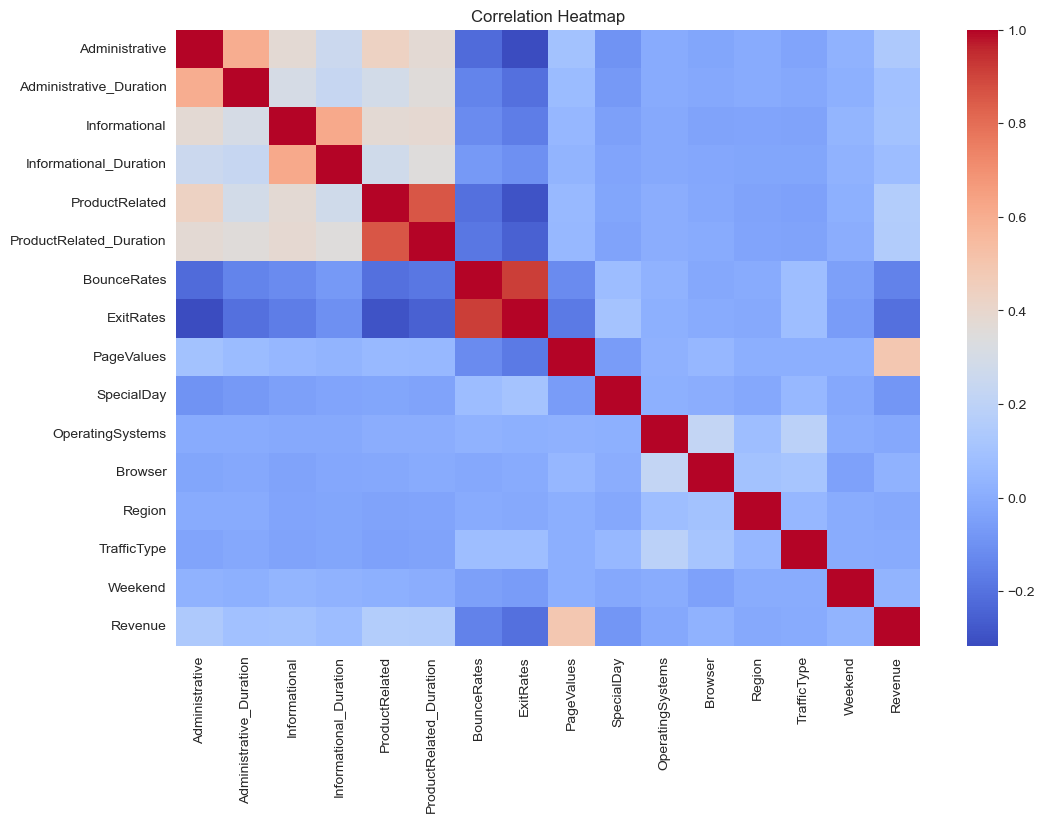

Revenue                    1.000000
PageValues                 0.492569
ProductRelated             0.158538
ProductRelated_Duration    0.152373
Administrative             0.138917
Informational              0.095200
Administrative_Duration    0.093587
Informational_Duration     0.070345
Weekend                    0.029295
Browser                    0.023984
TrafficType               -0.005113
Region                    -0.011595
OperatingSystems          -0.014668
SpecialDay                -0.082305
BounceRates               -0.150673
ExitRates                 -0.207071
Name: Revenue, dtype: float64

In [26]:
corr = df.corr(numeric_only=True)

plt.figure(figsize=(12,8))
sns.heatmap(corr, cmap="coolwarm", annot=False)
plt.title("Correlation Heatmap")
plt.show()

# Which features are most correlated with (relate most) with target
corr["Revenue"].sort_values(ascending=False)

# Feature vs Target

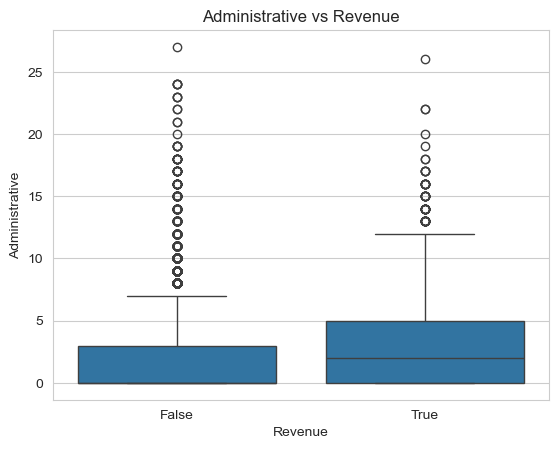

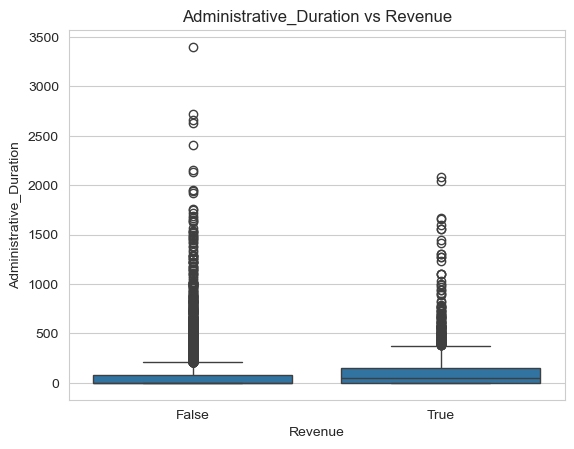

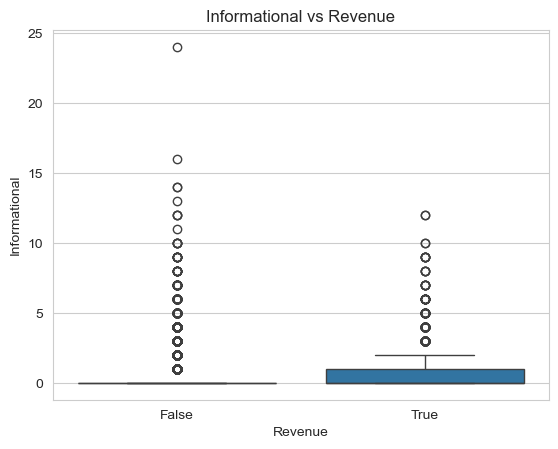

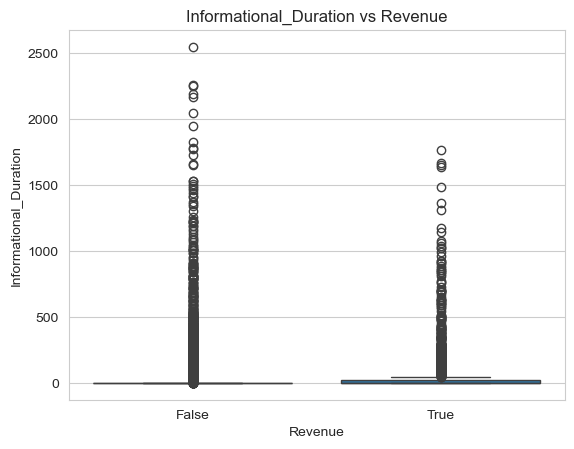

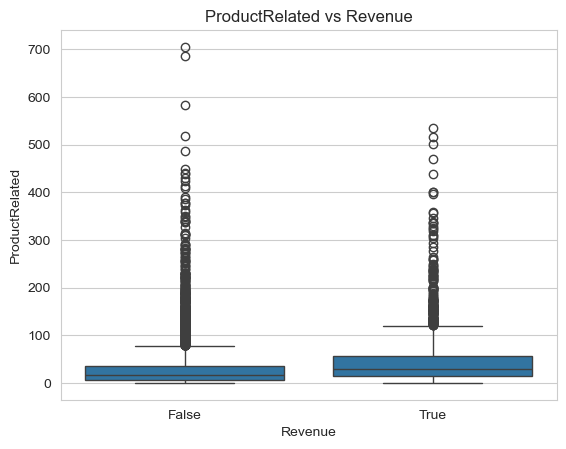

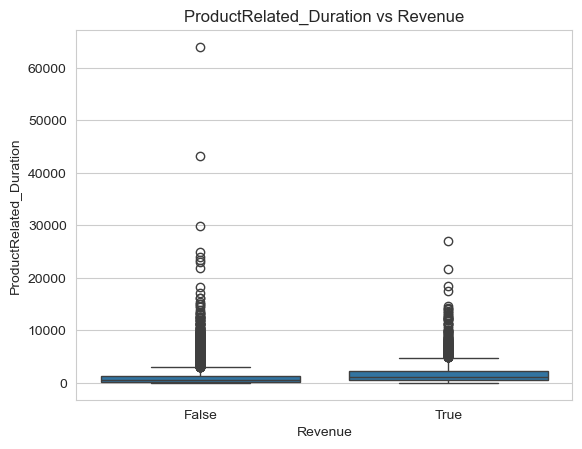

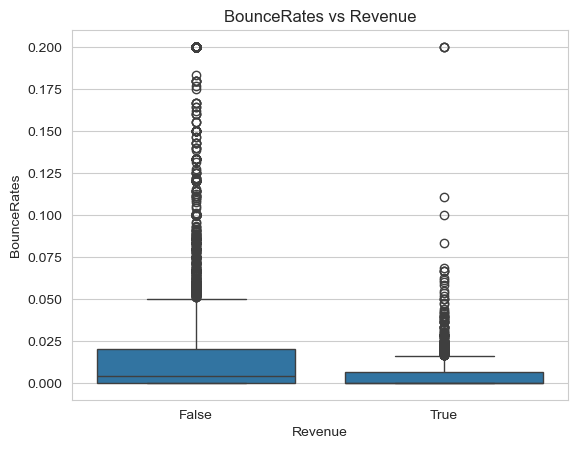

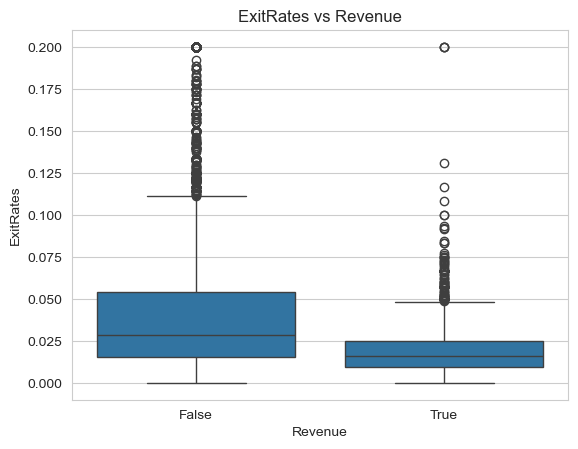

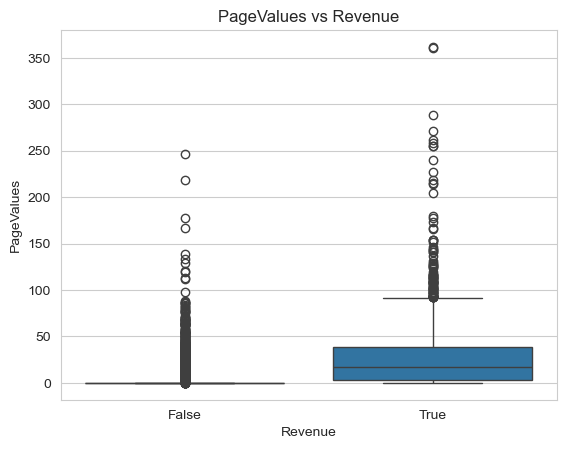

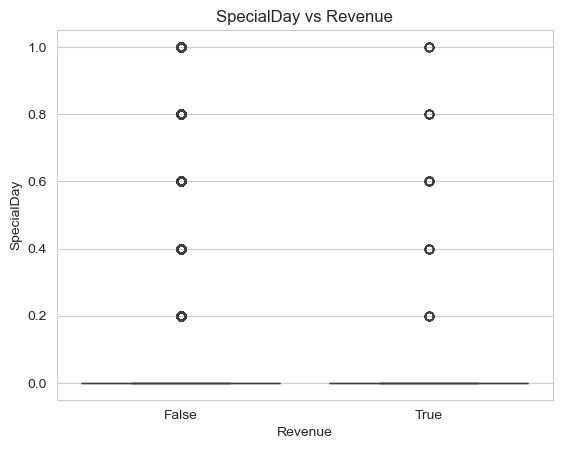

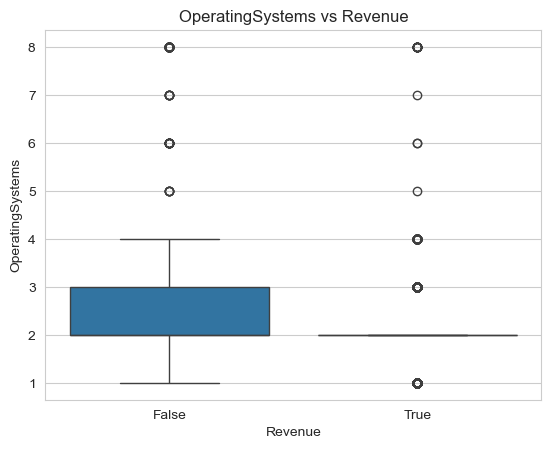

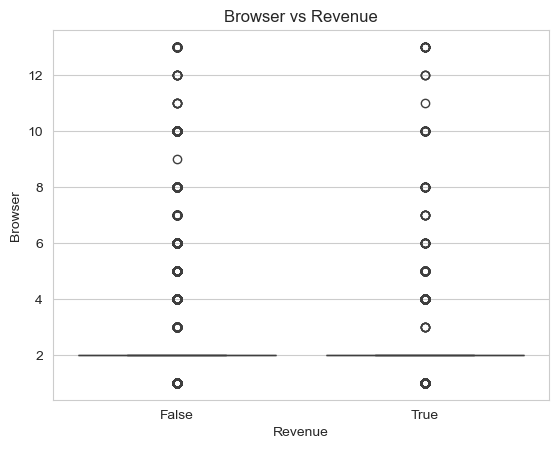

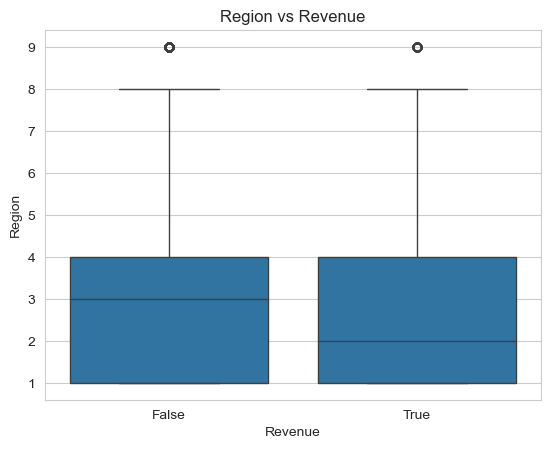

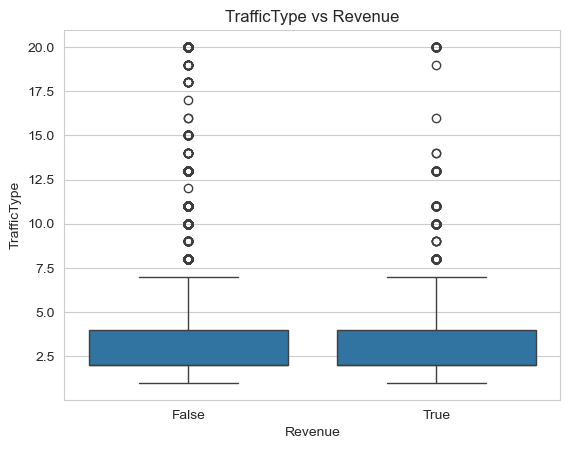

Revenue,False,True
Administrative,2.117732,3.393606
Administrative_Duration,73.740111,119.483244
Informational,0.451833,0.786164
Informational_Duration,30.236237,57.611427
ProductRelated,28.714642,48.210168
ProductRelated_Duration,1069.987809,1876.209615
BounceRates,0.025317,0.005117
ExitRates,0.047378,0.019555
PageValues,1.975998,27.264518
SpecialDay,0.068432,0.023166


In [27]:
for col in num_cols:
    sns.boxplot(x="Revenue", y=col, data=df)
    plt.title(f"{col} vs Revenue")
    plt.show()
    
# Means
df.groupby("Revenue")[num_cols].mean().T

# Categorical Analysis

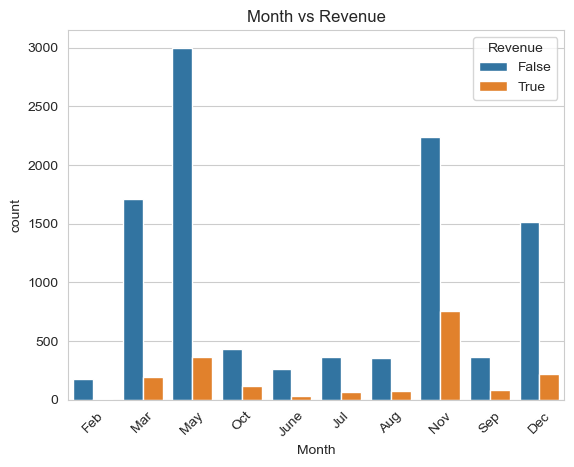

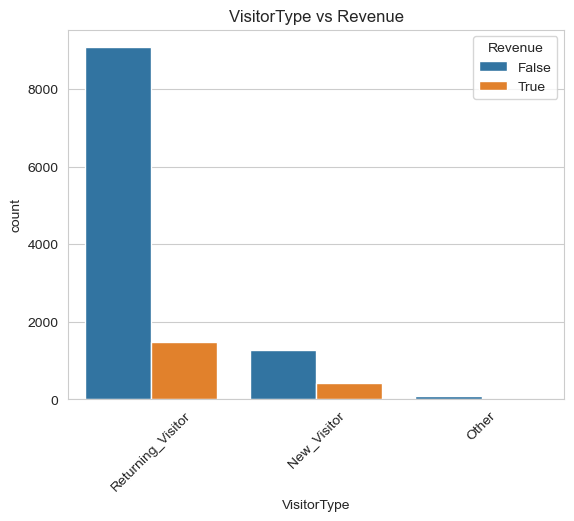

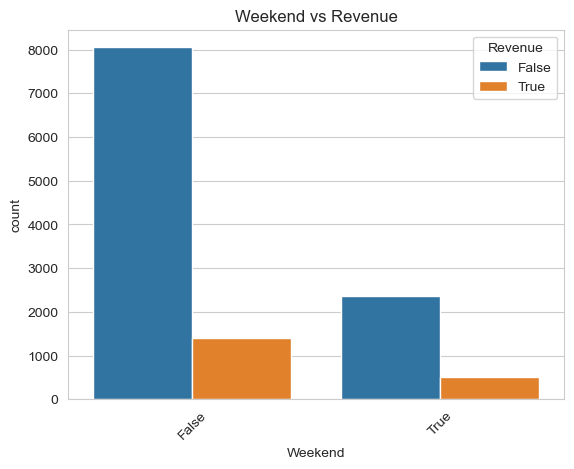

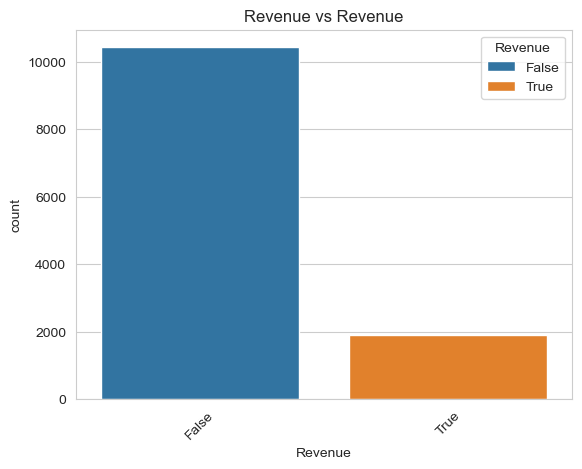


Month purchase rate:
Month
Aug     0.175520
Dec     0.125072
Feb     0.016304
Jul     0.152778
June    0.100694
Mar     0.100682
May     0.108502
Nov     0.253502
Oct     0.209472
Sep     0.191964
Name: Revenue, dtype: float64

VisitorType purchase rate:
VisitorType
New_Visitor          0.249115
Other                0.188235
Returning_Visitor    0.139323
Name: Revenue, dtype: float64

Weekend purchase rate:
Weekend
False    0.148911
True     0.173989
Name: Revenue, dtype: float64

Revenue purchase rate:
Revenue
False    0.0
True     1.0
Name: Revenue, dtype: float64


Informational_Duration     7.579185
ProductRelated_Duration    7.263228
PageValues                 6.382964
Administrative_Duration    5.615719
ProductRelated             4.341516
Informational              4.036464
SpecialDay                 3.302667
Browser                    3.242350
BounceRates                2.947855
ExitRates                  2.148789
OperatingSystems           2.066285
TrafficType                1.962987
Administrative             1.960357
dtype: float64

In [28]:
# Identify categorical columns
cat_cols = df.select_dtypes(include=["object", "bool"]).columns
cat_cols

# Count plots
for col in cat_cols:
    sns.countplot(x=col, hue="Revenue", data=df)
    plt.title(f"{col} vs Revenue")
    plt.xticks(rotation=45)
    plt.show()
    
# Purchase rate by category
for col in cat_cols:
    print(f"\n{col} purchase rate:")
    print(df.groupby(col)["Revenue"].mean())
    
# Log transform of skewed variables (identify variables needing transformation)
skewed = df[num_cols].skew().sort_values(ascending=False)

skewed[skewed > 1]